### <div style="background-color:blue; color:white; padding:10px;"> Imports </div>

In [52]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

from ultralytics import YOLO

### <div style="background-color:blue; color:white; padding:10px;"> Paths and parameters </div>

In [54]:
# Dataset paths
RGB_ROOT = r"D:\Datasets\Datasets\EPIC_Kitchen\RGB\P01_04\Original"
FLOW_ROOT = r"D:\Datasets\Datasets\EPIC_Kitchen\OpticalFlow\P01_04\P01_04"
ANNOTATION_CSV = r"D:\Datasets\Datasets\EPIC_Kitchen\Label\P01_04.csv"
# Output paths
OUTPUT_FEATURES_CSV = "../Features/P01_04_fused_features_updated.csv"
OUTPUT_LABELS_CSV = "../Labels/P01_04_labels_updated.csv"
# Model parameters
FEATURE_DIM = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


### <div style="background-color:blue; color:white; padding:10px;">Load annotation CSV</div>

In [55]:
annotations = pd.read_csv(ANNOTATION_CSV)
print("Total annotations:", len(annotations))
annotations.head()

Total annotations: 33


,StartFrame,EndFrame,Verb,Verb_class,Noun,Noun_class,ActionLabel,ActionName
0,6,182,take,0,cup,23,0,take cup
1,172,306,put-down,1,cup,23,1,put-down cup
2,369,406,take,0,bag:cereal,20,2,take bag:cereal
3,435,615,fold,46,bag:cereal,20,3,fold bag:cereal
4,621,846,put,1,bag:cereal,20,4,put bag:cereal


### <div style="background-color:blue; color:white; padding:10px;"> Create frame-level multi-label matrix </div>

In [56]:
max_frame = annotations['EndFrame'].max()
num_classes = annotations['ActionLabel'].nunique()
print("Total frames:", max_frame)
print("Total classes:", num_classes)

Total frames: 6180
Total classes: 29


In [57]:
labels = np.zeros((max_frame + 1, num_classes), dtype=np.float32)
for _, row in annotations.iterrows():    
    start = int(row['StartFrame'])
    end = int(row['EndFrame'])
    cls = int(row['ActionLabel'])    
    labels[start:end+1, cls] = 1.0
print("Labels shape:", labels.shape)

Labels shape: (6181, 29)


### <div style="background-color:blue; color:white; padding:10px;"> Define image transform </div>

In [58]:
transform = transforms.Compose([    
    transforms.Resize((224, 224)),    
    transforms.ToTensor(),    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### <div style="background-color:blue; color:white; padding:10px;">Load ResNet-50 feature extractor </div>

In [59]:
resnet = models.resnet50(weights=True)
# Remove classifier
modules = list(resnet.children())[:-1]
resnet = nn.Sequential(*modules)
# Add projection layer
projection = nn.Linear(2048, FEATURE_DIM)
resnet = resnet.to(DEVICE)
projection = projection.to(DEVICE)
resnet.eval()
projection.eval()

C:\Users\PAWANESH\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Linear(in_features=2048, out_features=512, bias=True)

In [60]:
yolo_model = YOLO("Model/yolov8n.pt")
# yolo_model.to(DEVICE)
yolo_model.to("cpu")

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

In [71]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torchvision.transforms as T
from pytorch_grad_cam import EigenCAM

target_layer = resnet[-2]   # last convolution block

cam = EigenCAM(model=resnet, target_layers=[target_layer])

In [72]:
def detect_objects(image_path):
    results = yolo_model(image_path, verbose=False)[0]
    boxes = results.boxes.xyxy.cpu().numpy()  # (N, 4)
    scores = results.boxes.conf.cpu().numpy()  # (N,)
    return boxes, scores

In [73]:
def compute_weights(boxes, scores, img_w, img_h, beta=5.0):
    center_frame = np.array([img_w/2, img_h/2])
    weights = []
    for box, score in zip(boxes, scores):
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        obj_center = np.array([cx, cy])
        dist = np.linalg.norm(obj_center - center_frame)
        dist_norm = dist / (np.linalg.norm(center_frame) + 1e-6)
        weight = score * np.exp(-beta * dist_norm)
        weights.append(weight)
    return np.array(weights)

In [74]:
@torch.no_grad()
def extract_object_features(image, boxes):
    
    obj_feats = []
    
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)
        
        crop = image.crop((x1, y1, x2, y2))
        crop = transform(crop).unsqueeze(0).to(DEVICE)
        
        feat = resnet(crop)
        feat = feat.view(1, -1)
        feat = projection(feat)
        
        obj_feats.append(feat.squeeze(0).cpu().numpy())
    
    if len(obj_feats) == 0:
        return np.zeros((1, FEATURE_DIM))
    
    return np.stack(obj_feats)

In [75]:
@torch.no_grad()
def extract_feature(image_path):    
    image = Image.open(image_path).convert("RGB")    
    image = transform(image).unsqueeze(0).to(DEVICE)    
    feature = resnet(image)    
    feature = feature.view(1, -1)    
    feature = projection(feature)    
    feature = feature.squeeze(0).cpu().numpy()    
    return feature

### <div style="background-color:blue; color:white; padding:10px;"> Load all frame paths</div>

In [76]:
rgb_frames = sorted(glob.glob(os.path.join(RGB_ROOT, "*.jpg")))
flow_frames = sorted(glob.glob(os.path.join(FLOW_ROOT, "*.jpg")))
assert len(rgb_frames) == len(flow_frames), "Mismatch in RGB and Flow frames"
num_frames = len(rgb_frames)
print("Total frames:", num_frames)

Total frames: 6180


###  <div style="background-color:blue; color:white; padding:10px;"> Visualization Function </div>

In [77]:
import cv2
import matplotlib.pyplot as plt

def visualize_yolo(image_path, yolo_model, top_k=5):    
    results = yolo_model(image_path, verbose=False)[0]    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)    
    if results.boxes is None:
        print("No detections")
        return    
    boxes = results.boxes.xyxy.cpu().numpy()
    scores = results.boxes.conf.cpu().numpy()
    classes = results.boxes.cls.cpu().numpy()   
    # Top-K filtering
    if len(scores) > 0:
        idx = np.argsort(scores)[-top_k:]
        boxes = boxes[idx]
        scores = scores[idx]
        classes = classes[idx]    
    for box, score, cls in zip(boxes, scores, classes):        
        x1, y1, x2, y2 = map(int, box)        
        # Draw rectangle
        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)        
        label = f"{int(cls)}: {score:.2f}"        
        cv2.putText(image, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)    
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("YOLO Detection")
    plt.show()

In [84]:
def visualize_multi_region(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224,224))

    rgb_img = img_resized.astype(np.float32) / 255.0

    input_tensor = transform(Image.fromarray(img_resized)).unsqueeze(0).to(DEVICE)

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6,6))
    plt.imshow(visualization)
    plt.axis("off")
    plt.title("Multi-Region Attention Map")
    plt.show()

Frame 0


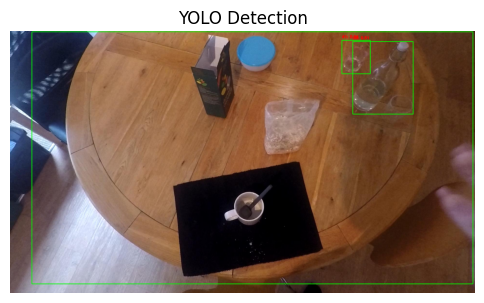

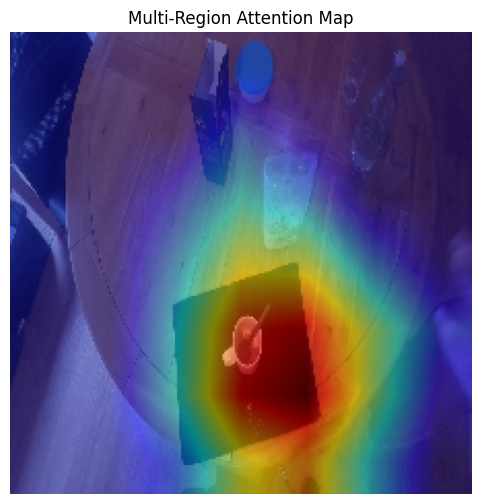

Frame 1


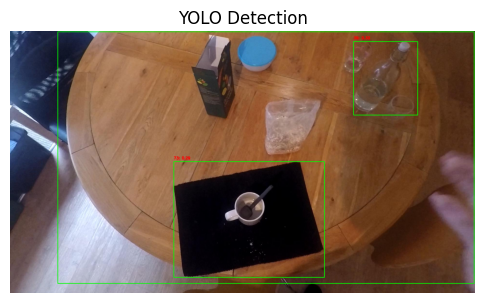

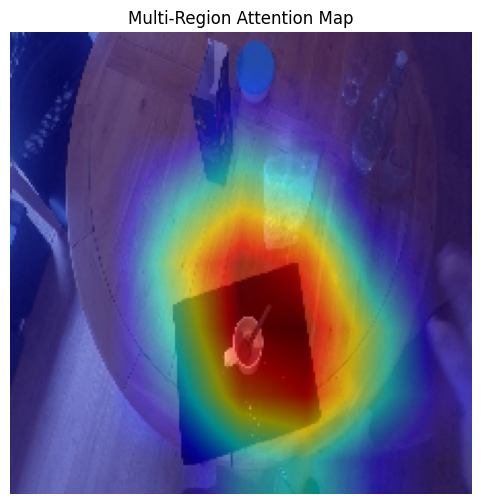

Frame 2


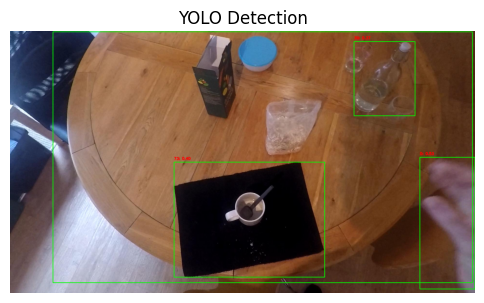

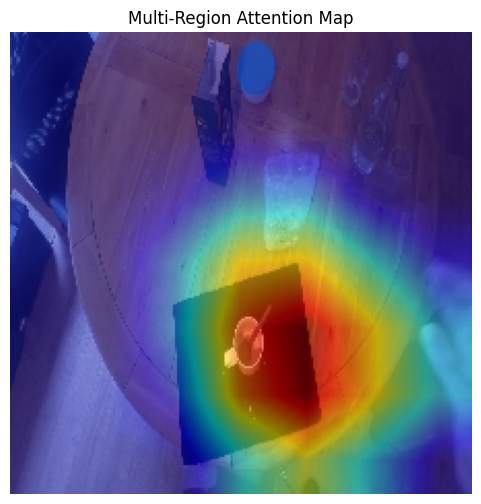

Frame 3


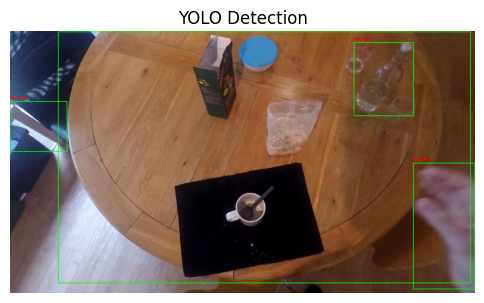

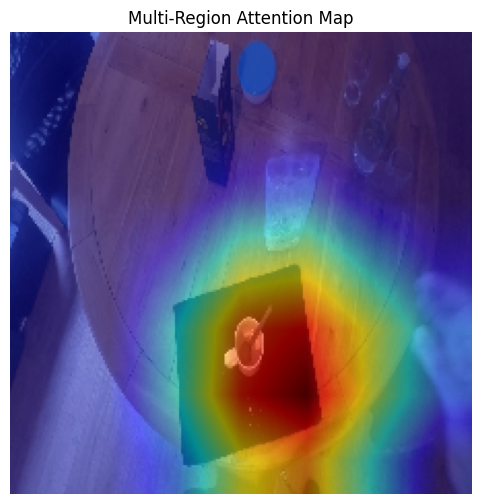

Frame 4


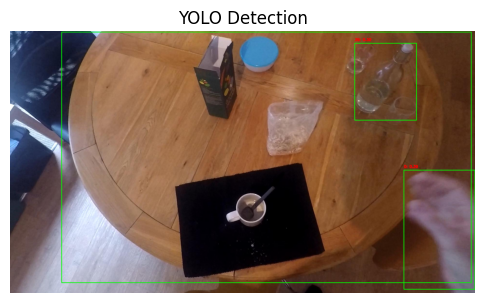

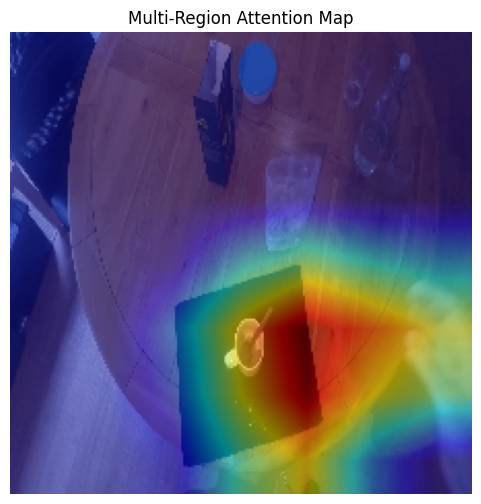

In [85]:
for i in range(5):

    print(f"Frame {i}")

    # YOLO bounding boxes
    visualize_yolo(rgb_frames[i], yolo_model, top_k=5)

    # Multi-region attention map
    visualize_multi_region(rgb_frames[i])

### <div style="background-color:blue; color:white; padding:10px;"> Extract RGB and Flow features </div>

In [ ]:
rgb_features = np.zeros((num_frames, FEATURE_DIM), dtype=np.float32)
flow_features = np.zeros((num_frames, FEATURE_DIM), dtype=np.float32)

gamma = 0.3
top_k = 3
for i in tqdm(range(num_frames), desc="Extracting features"):   
    rgb_feat = extract_feature(rgb_frames[i])
    flow_feat = extract_feature(flow_frames[i])    
    image = Image.open(rgb_frames[i]).convert("RGB")
    w, h = image.size    
    boxes, scores = detect_objects(rgb_frames[i])    
    if len(boxes) > 0:       
        idx = np.argsort(-scores)[:top_k]
        boxes = boxes[idx]
        scores = scores[idx]        
        weights = compute_weights(boxes, scores, w, h)
        obj_feats = extract_object_features(image, boxes)        
        if len(obj_feats) > 0:
            weights = weights / (np.sum(weights) + 1e-6)
            obj_feature = np.sum(weights[:, None] * obj_feats, axis=0)
        else:
            obj_feature = rgb_feat
    else:
        obj_feature = rgb_feat    
    obj_feature = obj_feature / (np.linalg.norm(obj_feature) + 1e-6)   
    combined_rgb = rgb_feat + gamma * obj_feature    
    rgb_features[i] = combined_rgb
    flow_features[i] = flow_feat

Extracting features:  95%|██████████████████████████████████████████████████████▍  | 5897/6180 [21:50<01:06,  4.25it/s]

In [51]:
print("RGB features:", rgb_features.shape)
print("Flow features:", flow_features.shape)

RGB features: (6180, 512)
Flow features: (6180, 512)


### <div style="background-color:blue; color:white; padding:10px;"> Adaptive multimodal fusion </div>

We implement adaptive fusion layer:

$$f_t=\alpha {f_t}^{rgb} + (1-\alpha) {f_t}^{flow}$$

In [52]:
class AdaptiveFusion(nn.Module):    
    def __init__(self, dim):        
        super().__init__()        
        self.fc = nn.Linear(dim * 2, 1)       
        self.sigmoid = nn.Sigmoid()   
    def forward(self, rgb, flow):        
        x = torch.cat([rgb, flow], dim=1)        
        alpha = self.sigmoid(self.fc(x))        
        fused = alpha * rgb + (1 - alpha) * flow        
        return fused

In [53]:
# Initialize fusion:
fusion_model = AdaptiveFusion(FEATURE_DIM).to(DEVICE)
fusion_model.eval()

AdaptiveFusion(
  (fc): Linear(in_features=1024, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [54]:
# Apply fusion:
rgb_tensor = torch.from_numpy(rgb_features).to(DEVICE)
flow_tensor = torch.from_numpy(flow_features).to(DEVICE)
with torch.no_grad():   
    fused_tensor = fusion_model(rgb_tensor, flow_tensor)
fused_features = fused_tensor.cpu().numpy()
fused_features = fused_features / (np.linalg.norm(fused_features, axis=1, keepdims=True) + 1e-6)
print("Fused features shape:", fused_features.shape)

Fused features shape: (6180, 512)


### <div style="background-color:blue; color:white; padding:10px;">Save fused features and labels to CSV </div>

In [55]:
features_df = pd.DataFrame(fused_features)
features_df.insert(0, "frame_id", np.arange(num_frames))
features_df.to_csv(OUTPUT_FEATURES_CSV, index=False)
print("Saved fused features:", OUTPUT_FEATURES_CSV)

Saved fused features: ../Features/P01_04_fused_features_updated.csv


In [56]:
# Correct alignment fix
num_frames = len(rgb_frames)
label_frames = labels.shape[0]
if label_frames < num_frames:    
    padding = np.zeros((num_frames - label_frames, labels.shape[1]), dtype=np.float32) 
    labels = np.vstack([labels, padding])
elif label_frames > num_frames:
    labels = labels[:num_frames]
print("Final labels shape:", labels.shape)
labels_df = pd.DataFrame(labels)
labels_df.insert(0, "frame_id", np.arange(num_frames))
labels_df.to_csv(OUTPUT_LABELS_CSV, index=False)
print("Saved labels:", OUTPUT_LABELS_CSV)

Final labels shape: (6180, 29)
Saved labels: ../Labels/P01_04_labels_updated.csv
